In [21]:
import pandas as pd

url = "https://raw.githubusercontent.com/murpi/wilddata/master/quests/churn_telecom.csv"
df = pd.read_csv(url)
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Yes
1,5575-GNVDE,Male,0,No,No,34,Yes,No,Fiber optic,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,Fiber optic,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
def quick_explore(dataframe):
    """Exploration rapide d'un DataFrame"""
    print('##### Observer les lignes #####')
    display(dataframe.head(10))
    print('\n')

    print('##### Dimensions du dataset #####')
    print(f'Lignes : {dataframe.shape[0]}, Colonnes : {dataframe.shape[1]}')
    print('\n')

    print('##### Informations sur les colonnes #####')
    print(dataframe.info())
    print('\n')

    print('##### Noms des colonnes #####')
    print(list(dataframe.columns))
    print('\n')

    print('##### Valeurs uniques #####')
    print(dataframe.nunique())
    print('\n')

    print('##### Description des colonnes numériques #####')
    stats = dataframe.describe(percentiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]).T
    print(stats.to_markdown())
    print('\n')

    print('##### Pourcentage de NaN par colonne #####')
    nan_percentage = (dataframe.isnull().sum() / len(dataframe)) * 100
    only_nan  = nan_percentage[nan_percentage > 0].sort_values(ascending=False)
    print(only_nan)
    print('\n')

    print('##### Nombre de doublons #####')
    print(dataframe.duplicated().sum(), 'doublon(s) trouvé(s)')
    print('\n')

    print('##### NaN par colonne #####')
    print(dataframe.isna().sum())

In [23]:
quick_explore(df)

##### Observer les lignes #####


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Yes
1,5575-GNVDE,Male,0,No,No,34,Yes,No,Fiber optic,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,Fiber optic,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,DSL,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,Fiber optic,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No




##### Dimensions du dataset #####
Lignes : 7043, Colonnes : 21


##### Informations sur les colonnes #####
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str 

In [24]:
# Je modifie le type de ma colonne totalcharges

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [25]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

Je traduis les colonnes :

- customerID : Numéro Client
- gender : Genre
- SeniorCitizen : Personne Âgée (+ de 65 ans)
- Partner : Partenaire
- Dependents : Personnes à charge
- tenure : Ancienneté (en mois)
- PhoneService : Service Téléphonique
- MultipleLines : Lignes Multiples
- InternetService : Service Internet
- OnlineSecurity : Sécurité en Ligne
- OnlineBackup : Sauvegarde en Ligne
- DeviceProtection : Protection des Appareils
- TechSupport : Support Technique
- StreamingTV : Streaming TV
- StreamingMovies : Streaming Films
- Contract : Type de Contrat
- PaperlessBilling : Facturation Dématérialisée
- PaymentMethod : Méthode de Paiement
- MonthlyCharges : Charges Mensuelles
- TotalCharges : Charges Totales
- Churn : Désabonnement

In [26]:
# Je calcule le taux d'attrition (nombre de resiliations/nombre total de clients)

# Je crée une condition pour récuperer les lignes ou il y a un Yes dans Churn qui représente le nombre de resiliations
churn = df['Churn'] == "Yes"
len(df[churn])

# Je divise le nombre de résiliations par la longueur de clients avec len
tx_attrition = round((len(df[churn]) / len(df)),2)
print(f"Le taux d'attrition est : {tx_attrition}")

Le taux d'attrition est : 0.32


- Il y a 32% des clients qui ont résilié

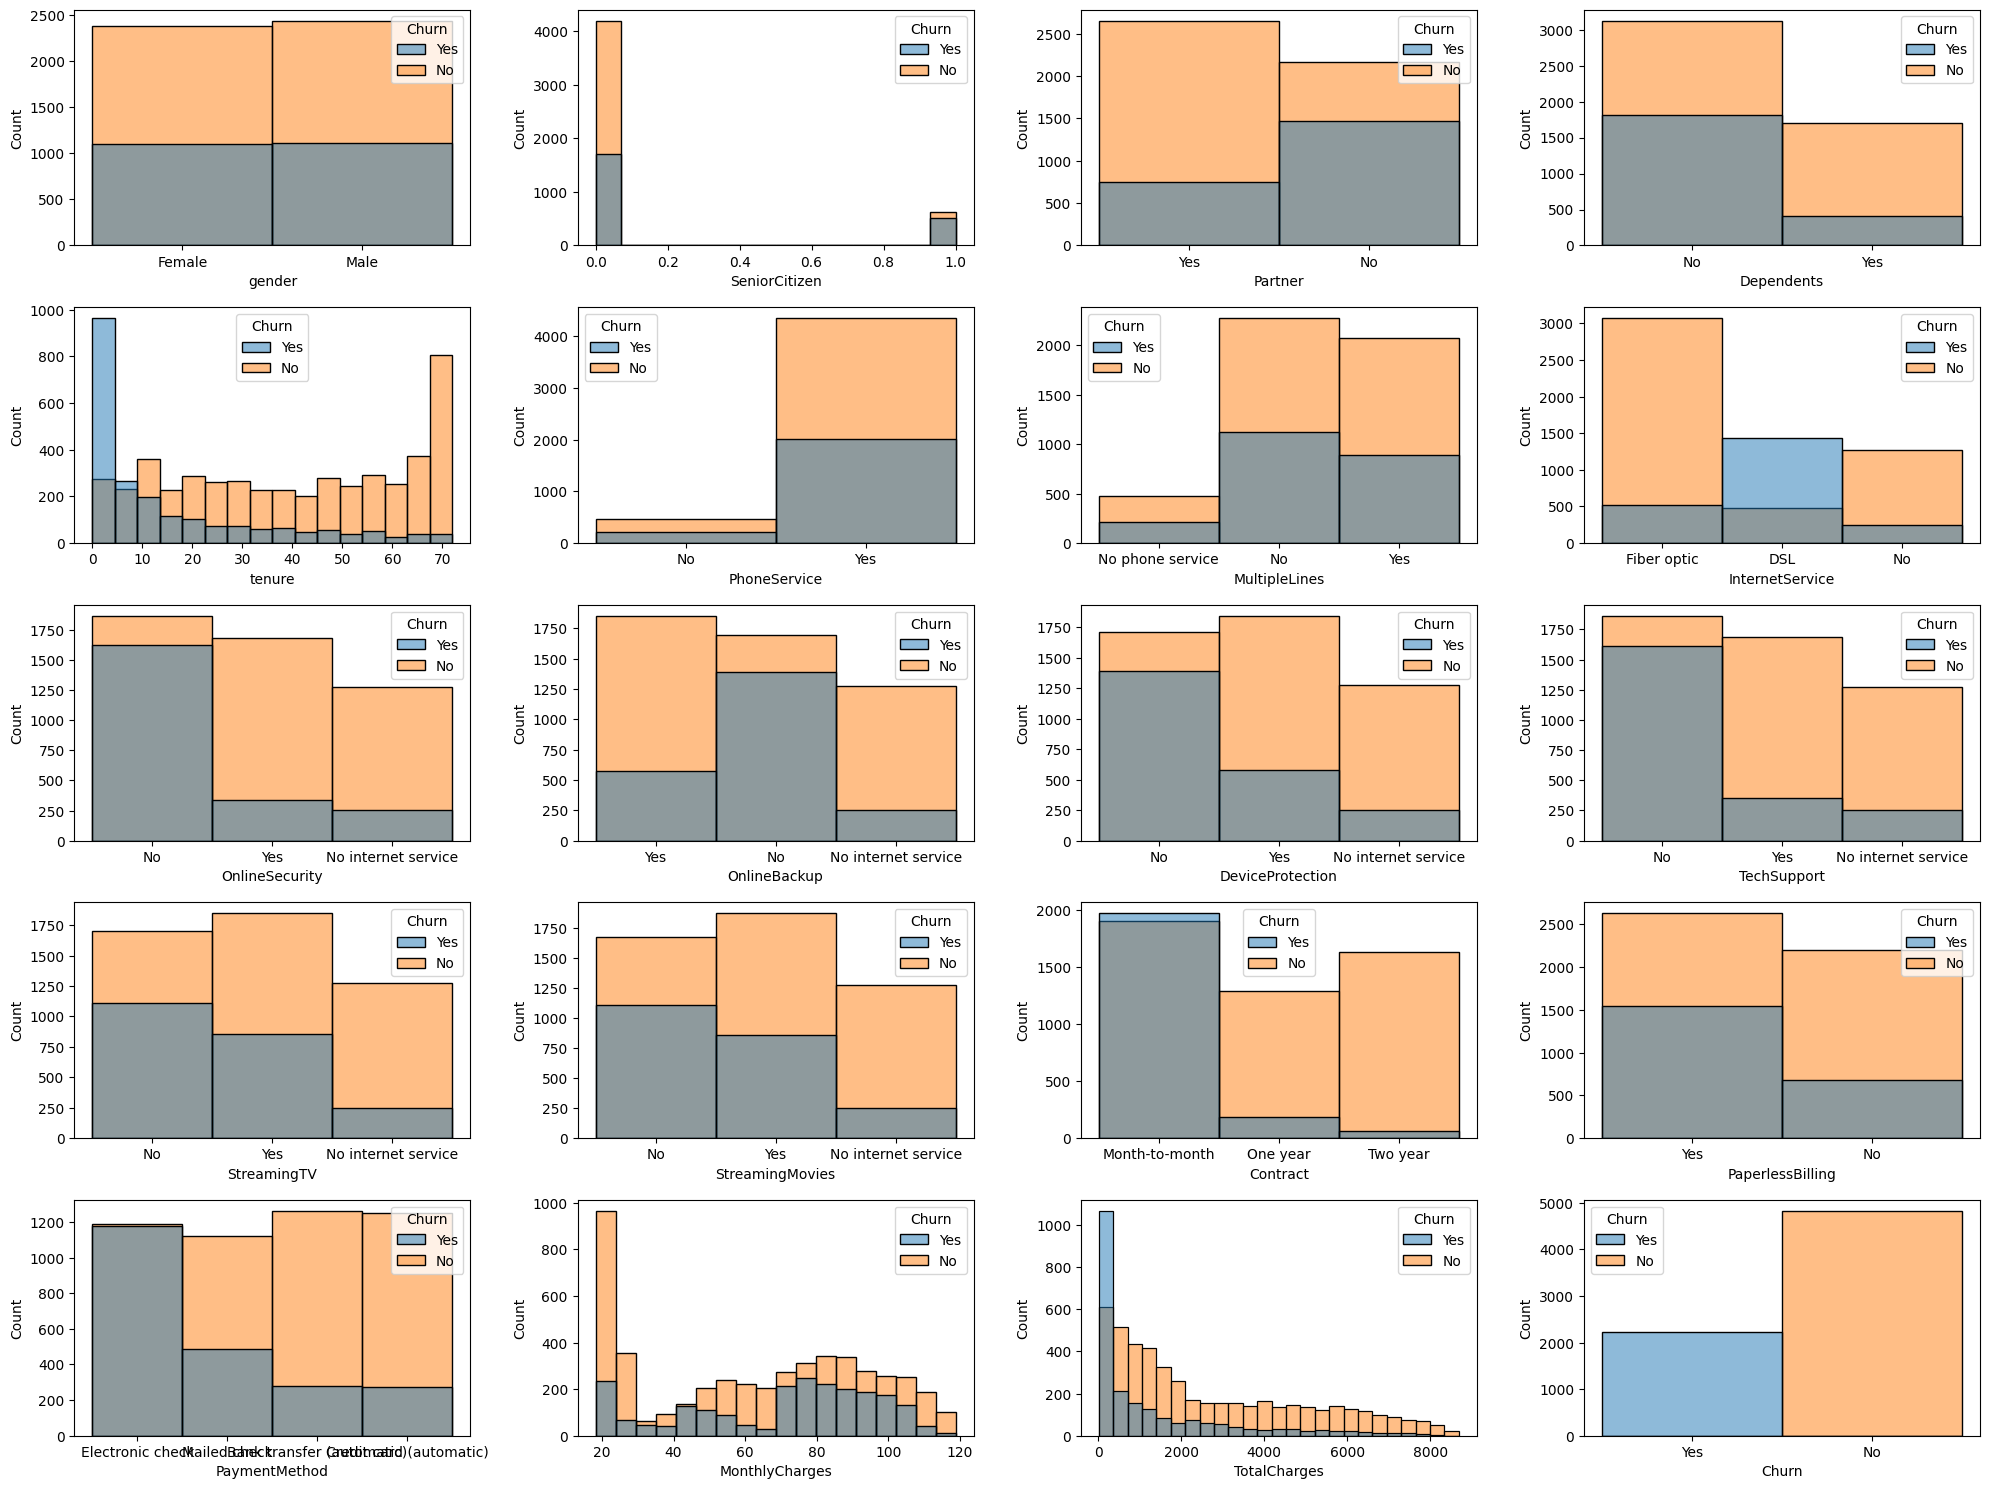

In [27]:
# Je crée un graphique par colonne en comparant les clients résiliés et les non résiliés
import matplotlib.pyplot as plt 
import seaborn as sns

# Je crée un df sans la colonne customerid
df2 = df.drop(columns='customerID')

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 15))
axes = axes.flatten()  # transforme la grille en liste simple

for i, col in enumerate(df2.columns):
    if df[col].dtype == 'object':
        sns.countplot(data=df2, x=col, hue='Churn', ax=axes[i], dodge=True)
    else :
        sns.histplot(data=df2, x=col, hue='Churn', ax=axes[i], multiple="layer") 
    
plt.tight_layout()
plt.show()

- Pour les valeurs numériques : 
    - Les clients qui résilient ont des charges mensuelles plus élevées (graphique 17)

- Pour les valeurs catégorielles :
    - Les contrat au mois connaissent beaucoup plus de résiliations que les contrats de deux ans d'abonnement
    - Les contrats récents ont beaucoup plus de résiliations, plus le temps passe moins les gens résilient
    - Les clients avec la fibre résilient moins que les client avec DSL
    - Ceux qui ont la sécurité en ligne résilient moins que ceux qui ne l'ont pas


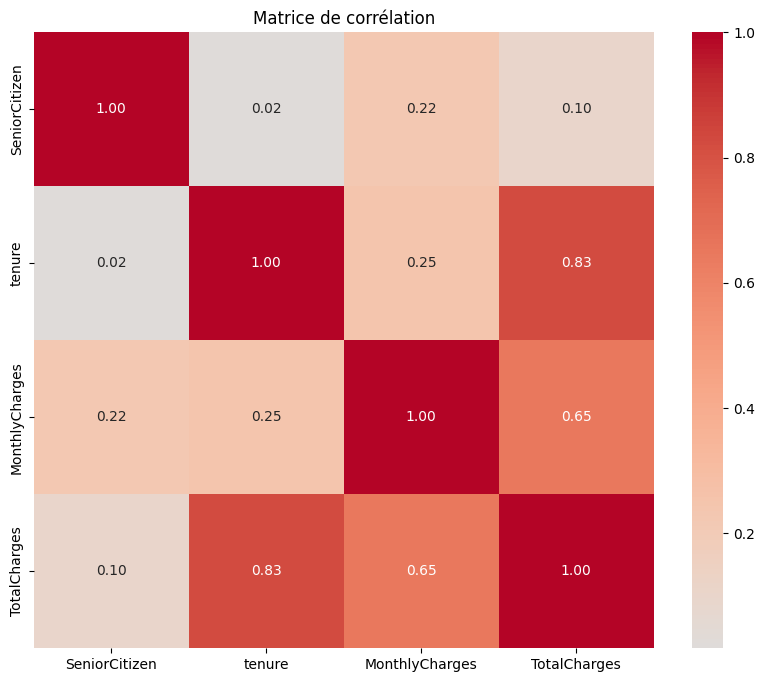

In [28]:
# Je fais une matrice de correlation

# sns_heatmap : Matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matrice de corrélation')
plt.show()

# Oral : 'Cette heatmap montre les corrélations entre variables numériques. Les couleurs chaudes = corrélation positive forte.'

- Il y a une forte corrélation positive entre le total des charges et l'ancienneté, il y a aussi une correlation positive relative entre monthlycharges et totalcharges. Pour le reste la correlation est faible voir nulle

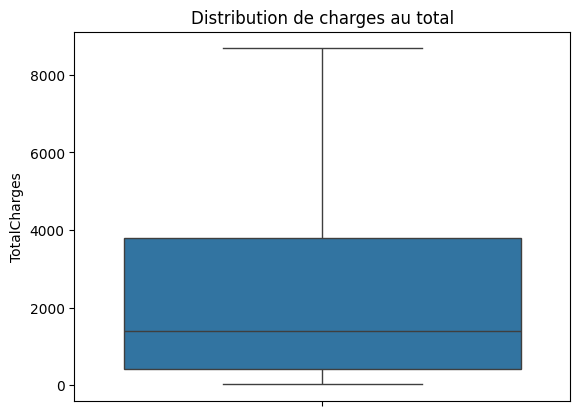

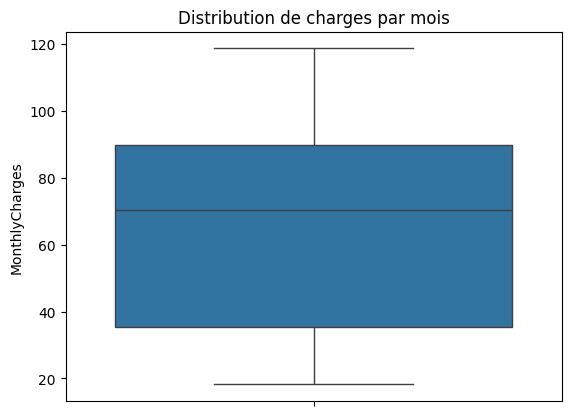

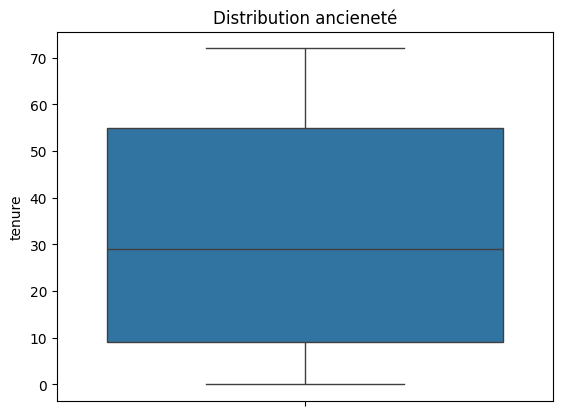

In [29]:
# sns_boxplot : Visualise la distribution + outliers
sns.boxplot(data=df, y='TotalCharges')
plt.title('Distribution de charges au total')
plt.show()

# Oral : 'Le boxplot montre la médiane, les quartiles et les outliers. Très utile pour comparer des distributions entre groupes.'

sns.boxplot(data=df, y='MonthlyCharges')
plt.title('Distribution de charges par mois')
plt.show()

sns.boxplot(data=df, y='tenure')
plt.title('Distribution ancieneté')
plt.show()

- Maintenant je vais déterminer les clusters des clients avec l'algorithme K-Means après avoir vérifié grace aux boxplot qu'il n'y avait pas de valeurs aberrantes


In [76]:
# Je vais créer un df_encoded avec toutes les données categorielles encodées et j'exclue customerID
df_encoded = pd.get_dummies(df.drop(columns=['customerID']), drop_first=True).astype(int)

# Je réintegre customerID pour avoir les id plus tard lorsque j'en aurais besoin sur Power BI pour les jointures
df_encoded['customerID'] = df['customerID'].values
print(df_encoded.shape)

(7043, 32)


In [77]:
df_encoded.sample(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes,customerID
2668,0,1,19,19,1,0,1,1,0,0,...,1,0,0,0,0,0,0,1,1,6849-WLEYG
4708,0,56,61,3346,0,1,1,1,0,0,...,0,0,0,1,1,1,0,0,0,5181-OABFK
4426,0,16,79,1264,0,0,1,1,0,1,...,0,0,1,0,1,1,0,0,0,8652-YHIYU
5463,0,1,44,44,0,1,1,1,0,0,...,0,0,0,0,1,0,0,0,1,6142-VSJQO
92,0,66,84,5714,1,1,1,1,0,1,...,0,1,0,1,1,0,0,1,0,7233-PAHHL
2153,0,25,74,1797,0,1,0,1,0,0,...,0,0,0,0,1,0,1,0,0,7978-DKUQH
5540,0,1,20,20,0,1,1,1,0,0,...,1,0,0,0,0,0,0,1,1,3803-KMQFW
2436,1,31,73,2094,0,0,0,1,0,0,...,0,0,0,0,1,1,0,0,0,6360-SVNWV
2523,0,47,20,873,0,1,1,1,0,0,...,1,0,0,1,0,1,0,0,0,9081-WWXKP
1926,0,49,99,4872,1,1,1,1,0,1,...,0,1,0,0,1,0,1,0,1,6651-AZVTJ


In [78]:
# Je définis mes features, tout le dataframe sauf customerID

X = df_encoded.drop(columns=['customerID'])

In [79]:
# Je standardise mes données

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

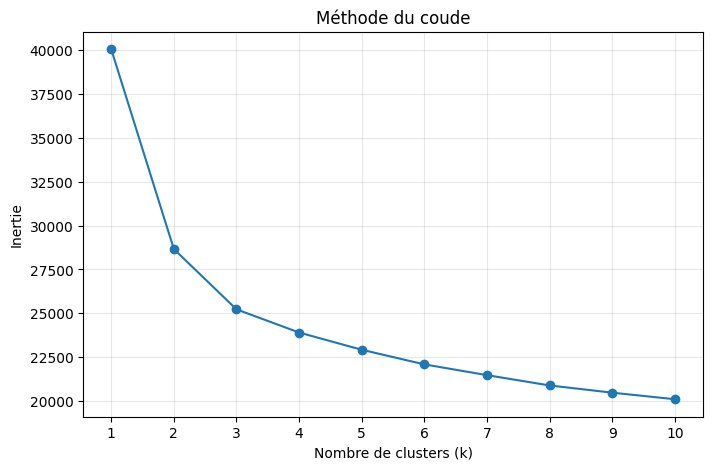

In [80]:
# J'utilise l'elbow method pour choisir le bon nombre de clusters

# Méthode du coude pour trouver le nombre optimal de clusters
from sklearn.cluster import KMeans

def elbow_method(data, max_k=10):
    inertia = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
        kmeans.fit(data)
        inertia.append(kmeans.inertia_)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), inertia, marker='o')
    plt.title('Méthode du coude')
    plt.xlabel('Nombre de clusters (k)')
    plt.ylabel('Inertie')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True, alpha=0.3)
    plt.show()

# Oral : "La méthode du coude permet de visualiser l'inertie en fonction du nombre de clusters. 
# Le point où l'inertie commence à diminuer moins rapidement est souvent considéré comme le nombre optimal de clusters."

elbow_method(X_scaled)

- Ici, le bon nombre de clusters et a 3, le coude commence a s'applatir a ce moment la. L'inertie baisse beaucoup avant et ensuite elle descend doucement, c'est le bon compromis.

In [81]:
# J'instancie mon modèle

model = KMeans(n_clusters=3)

In [82]:
# J'entraine mon modèle

model = model.fit(X_scaled)

c:\Users\user\QueteWCS\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [83]:
# J'ajoute une colonne cluster avec les labels grace a labels_ a mon dataframe

df_encoded['cluster'] = model.labels_

<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

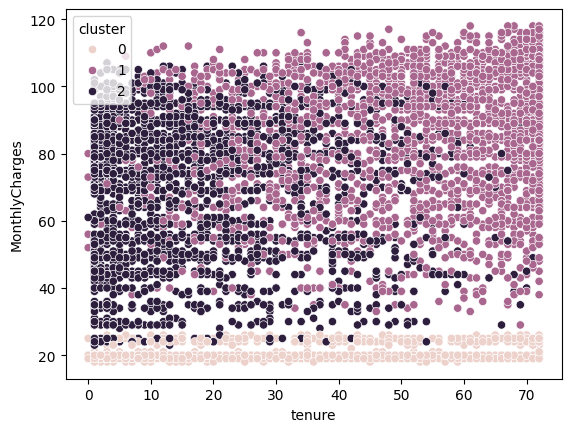

In [84]:
# Je visualise les clusters avec un scatterplot

sns.scatterplot(data=df_encoded, x='tenure', y='MonthlyCharges', hue='cluster')

<Axes: xlabel='PCA1', ylabel='PCA2'>

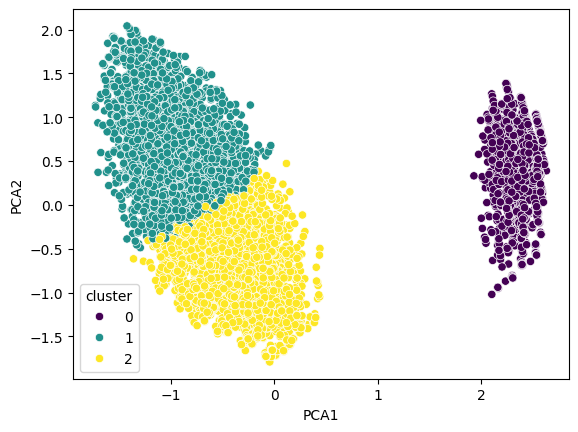

In [85]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

df_encoded['PCA1'] = coords[:, 0]
df_encoded['PCA2'] = coords[:, 1]

sns.scatterplot(data=df_encoded, x='PCA1', y='PCA2', hue='cluster', palette='viridis')

In [86]:
# Je vais maintenant prédire qui risque de résilier chez les nouveau clients. Je définis ma cible et mes features

X = df_encoded.drop(columns=['Churn_Yes', 'cluster', 'PCA1', 'PCA2', 'customerID'])
y = df_encoded['Churn_Yes']

In [87]:
# J'applique mon train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [88]:
# J'instancie mon modele
from sklearn.linear_model import LogisticRegression

regression = LogisticRegression(max_iter=1000)

In [89]:
# J'entraine mon modele

model = regression.fit(X_train, y_train)

In [90]:
# J'effectue mes predictions

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [91]:
# J'évalue avec les métriques adaptées pour la classification : accuracy, rapport de classification et matrice de confusion
from sklearn.metrics import accuracy_score

accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)
print(f"Le score sur le train est : {accuracy_train:.2f}")
print(f"Le score sur le test est : {accuracy_test:.2f}")

Le score sur le train est : 0.88
Le score sur le test est : 0.87


- Le modèle prédit correctement 88% des cas sur les données d'entrainement
- Le modèle prédit correctement 87% des cas sur les données de test

- L'écart train/test est de seulement 1%, le modèle se généralise bien
- Pas d'overfitting, le modèle n'a pas juste mémorisé les données d'entrainement
- Pas d'underfitting, les scores sont élevés le modèle a bien appris
- Il y a un goodfitting

In [92]:
# J'utilise le classification report et je décris que représente chaque resultat
from sklearn.metrics import classification_report

classification = classification_report(y_test, y_test_pred)
print(classification)

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       959
           1       0.82      0.77      0.79       450

    accuracy                           0.87      1409
   macro avg       0.86      0.85      0.85      1409
weighted avg       0.87      0.87      0.87      1409



- PRECISION veut dire que sur tous les clients prédits comme "résiliant" 82% l'ont vraiment fait pour la classe 1 et pour la classe 0, tous les clients prédits comme "non-résiliants" 90% n'ont en effet pas résilié

- RECALL sur tous les clients qui ont vraiment résilié, 77% ont vraiment résilié, même principe pour la classe 0

- F1 SCORE c'est la moyenne harmonique entre precision et recall, cela donne une version globale 

- SUPPORT ce sont les cas réels pour chaque classe 

- 959 dans la classe 0 et 450 dans la classe 1, il y a un déséquilibre de classes

- Pour un cas métier réel, on privilégierait le recall sur la classe 1, mieux vaut contacter un client qui ne partait pas que rater un client qui part

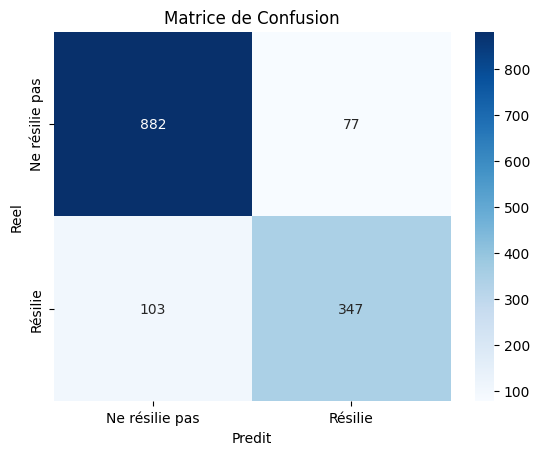

In [93]:
# J'affiche une matrice de confusion
from sklearn.metrics import confusion_matrix

matrice_confusion = confusion_matrix(y_test, y_test_pred)

def matrice_confusion(y_test, y_pred, labels=None):
    """
    Afficher la matrice de confusion
    Avec labels : matrice_confusion(y_test, y_pred, labels=['Non', 'Oui'])
    """
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predit')
    plt.ylabel('Reel')
    plt.title('Matrice de Confusion')
    plt.show()

matrice_confusion(y_test, y_test_pred, labels=['Ne résilie pas', 'Résilie'])

- 882 clients prédits comme ne resiliant pas ne résilient pas (Bien détectés)
- 77 clients prédits comme résiliant et qui ne résilient pas (Mal détectés)

- 103 clients prédits comme ne résiliant pas et qui résilient (Mal détectés)
- 347 clients prédits comme résiliant résilient vraiment (Bien détectés)

- Le probème est les 103 clients qui sont des clients qui vont partir sans qu'on le détecte

In [107]:
# Probabilités de résiliation (colonne 1 = classe Oui)
probas = regression.predict_proba(X_test)[:, 1]

# Ajouter au dataframe
df_risque = X_test.copy()
df_risque['probabilite_resiliation'] = probas

# Trier par risque décroissant
df_risque = df_risque.sort_values('probabilite_resiliation', ascending=False)

print(df_risque['probabilite_resiliation'].head(10))

display(df_risque['probabilite_resiliation'])

2191    0.992885
534     0.992803
3551    0.992063
4800    0.991296
1056    0.991271
3805    0.991266
3276    0.990999
3467    0.990990
3352    0.990988
346     0.990977
Name: probabilite_resiliation, dtype: float64


2191    0.992885
534     0.992803
3551    0.992063
4800    0.991296
1056    0.991271
          ...   
4201    0.000096
1379    0.000090
932     0.000085
5740    0.000078
216     0.000065
Name: probabilite_resiliation, Length: 1409, dtype: float64

In [95]:
# Je détermine les variables qui ont le plus d'impact sur l'algorithme grace a .coef_

features = X.columns
coefficients = regression.coef_[0]

df_importance = pd.DataFrame({
    'feature': features,
    'coefficient': coefficients
}).sort_values('coefficient', ascending=False)

print(df_importance)

                                  feature  coefficient
8          MultipleLines_No phone service     1.512868
28         PaymentMethod_Electronic check     0.439025
29             PaymentMethod_Mailed check     0.212239
0                           SeniorCitizen     0.121597
27  PaymentMethod_Credit card (automatic)     0.099482
26                   PaperlessBilling_Yes     0.090421
2                          MonthlyCharges     0.064647
3                            TotalCharges     0.001087
6                          Dependents_Yes    -0.025242
4                             gender_Male    -0.079405
18        TechSupport_No internet service    -0.089067
16   DeviceProtection_No internet service    -0.089067
14       OnlineBackup_No internet service    -0.089067
12     OnlineSecurity_No internet service    -0.089067
22    StreamingMovies_No internet service    -0.089067
11                     InternetService_No    -0.089067
20        StreamingTV_No internet service    -0.089067
5         

- Variables qui poussent vers la résiliation (coefficients positifs)
    - MultipleLines_No phone service (1.51) → le plus fort
    - PaymentMethod_Electronic check (0.44) → paiement par chèque électronique risqué
    - SeniorCitizen (0.12) → les seniors réslient plus

- Variables qui retiennent le client (coefficients négatifs)
    - InternetService_Fiber optic (-4.10) → surprenant, à analyser
    - Contract_Two year (-1.07) → contrat long = client fidèle ✅ logique
    - TechSupport_Yes (-0.99) → support technique = client satisfait
    - OnlineSecurity_Yes (-0.95) → sécurité en ligne = client retained

"Les clients sans contrat long terme et payant par chèque électronique sont les plus à risque"
"Proposer un contrat 2 ans et du support technique réduit significativement le churn"

In [98]:
# Je rajoute les id a mon df_risque
df_risque['customerID'] = df.loc[X_test.index, 'customerID'].values

In [102]:
# J'exporte tous mes fichiers en csv pour travailler sur Power BI

df_risque.to_csv('df_risque.csv', index=False)
df_importance.to_csv('df_importance.csv', index=False)
df_encoded.to_csv('df_encoded.csv', index=False)

In [99]:
df_encoded.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes', 'customerID', 'cluster', 'PCA1', 'PCA2'],
      dtype='str')

In [103]:
top5_positifs = df_importance[df_importance['coefficient'] > 0].head(5)
top5_negatifs = df_importance[df_importance['coefficient'] < 0].tail(5)
df_importance_top10 = pd.concat([top5_positifs, top5_negatifs])
df_importance_top10.to_csv('df_importance_top10.csv', index=False)

In [104]:
df.to_csv('df_initial.csv', index=False)